In [4]:
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import warnings
warnings.filterwarnings('ignore')

In [6]:
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)


In [ ]:
data = pd.read_csv('../data/processed/processed_stock_data.csv')
data['Date'] = pd.to_datetime(data['Date']) # function to convert type data('2024-01-15') from string tp Timestamp('2024-01-15 00:00:00')


In [9]:
print(f" Dataset shape: {data.shape}")
print(f"Date range: {data['Date'].min().date()} → {data['Date'].max().date()}")
print(f"Tickers: {list(data['Ticker'].unique())}")
print(f"\n Columns: {list(data.columns)}")
data.head()


 Dataset shape: (8442, 15)
Date range: 2021-06-07 → 2026-03-25
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']

 Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'SMA_20', 'SMA_50', 'RSI_14', 'MACD', 'MACD_Signal', 'Bollinger_Upper', 'Bollinger_Lower', 'Target_Direction']


,Date,Open,High,Low,Close,Volume,Ticker,SMA_20,SMA_50,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Target_Direction
0,2021-06-07,123.097765,123.244114,121.790398,122.834343,71057600,AAPL,122.537245,125.013458,48.785329,-0.852041,-0.870258,125.042355,120.032135,1
1,2021-06-08,123.517287,125.332004,123.136784,123.653877,74403800,AAPL,122.531879,125.125376,56.450591,-0.698815,-0.835969,125.026389,120.037370,1
2,2021-06-09,124.112432,124.639284,123.439231,124.034378,56877900,AAPL,122.591393,125.241397,58.198951,-0.540448,-0.776865,125.172557,120.010230,0
3,2021-06-10,123.927045,125.068561,122.873349,123.039207,71186400,AAPL,122.754326,125.366540,45.481916,-0.489600,-0.719412,124.974576,120.534076,1
4,2021-06-11,123.448976,124.336821,123.029446,124.249008,53522400,AAPL,122.870428,125.472049,57.594902,-0.347673,-0.645064,125.150554,120.590303,1


In [ ]:
# chevk the balance in target 
print(" Target Distribution (all data):")
print(data['Target_Direction'].value_counts())
print(f"\nBalance ratio: {data['Target_Direction'].mean():.2%} UP vs {1 - data['Target_Direction'].mean():.2%} DOWN")

# Samples per ticker
print("\n Samples per ticker:")
print(data.groupby('Ticker').size()) # Groups rows by ticker name to check if all days are avilable 

 Target Distribution (all data):
Target_Direction
1    4412
0    4030
Name: count, dtype: int64

Balance ratio: 52.26% UP vs 47.74% DOWN

 Samples per ticker:
Ticker
AAPL     1206
AMZN     1206
GOOGL    1206
META     1206
MSFT     1206
NVDA     1206
TSLA     1206
dtype: int64


In [14]:
# Features the model will use (12 features)
FEATURE_COLS = ['Open', 'High', 'Low', 'Close', 'Volume',
                'SMA_20', 'SMA_50', 'RSI_14', 'MACD', 'MACD_Signal',
                'Bollinger_Upper', 'Bollinger_Lower']

TARGET_COL = 'Target_Direction'

# Config values
WINDOW_SIZE = config['data']['window_size']  # 30 days
TRAIN_END = config['data']['train_end_date']
VAL_END = config['data']['val_end_date']
TEST_END = config['data']['test_end_date']

print(f"Features: {len(FEATURE_COLS)} columns")
print(f"Window size: {WINDOW_SIZE} days")
print(f"Train period: up to {TRAIN_END}")
print(f"Val period: {TRAIN_END} → {VAL_END}")
print(f"Test period: after {VAL_END} to {TEST_END}")

Features: 12 columns
Window size: 30 days
Train period: up to 2024-03-31
Val period: 2024-03-31 → 2025-03-31
Test period: after 2025-03-31 to 2026-03-25


In [18]:
def create_sequences(features, targets, window_size):
    """
    Create sliding window sequences.
    Input: features array (N, 12), targets array (N,)
    Output: X (samples, window_size, 12), y (samples,)
    """
    X, y = [], []
    for i in range(window_size, len(features)): # renge from 30 to 1206 end of data
        X.append(features[i - window_size:i])  # 30 days of features
        y.append(targets[i])                    # Target of the last day
    return np.array(X), np.array(y)


# Process each ticker: Scale → Create Sequences → Split by Date
X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []
X_test_list, y_test_list = [], []

scalers = {}
    
for ticker in sorted(data['Ticker'].unique()):
    ticker_df = data[data['Ticker'] == ticker].sort_values('Date').reset_index(drop=True)

    # ---- Step 1: Fit scaler on TRAIN data only (prevent data leakage) ----
    train_mask = ticker_df['Date'] <= TRAIN_END
    scaler = MinMaxScaler()
    scaler.fit(ticker_df.loc[train_mask, FEATURE_COLS]) # mask is rows , features is cols and apply scaler just on train
    scalers[ticker] = scaler

    # ---- Step 2: Scale ALL data using the train-fitted scaler ----
    scaled_features = scaler.transform(ticker_df[FEATURE_COLS])
    targets = ticker_df[TARGET_COL].values
    dates = ticker_df['Date'].values

    # ---- Step 3: Create sliding window sequences ----
    X_seq, y_seq = create_sequences(scaled_features, targets, WINDOW_SIZE)
    # Each sequence's "date" is the last day in the window
    seq_dates = dates[WINDOW_SIZE:]

    # ---- Step 4: Split sequences by date ----
    train_idx = seq_dates <= np.datetime64(TRAIN_END)
    val_idx = (seq_dates > np.datetime64(TRAIN_END)) & (seq_dates <= np.datetime64(VAL_END))
    test_idx = seq_dates > np.datetime64(VAL_END)

    X_train_list.append(X_seq[train_idx])
    y_train_list.append(y_seq[train_idx])
    X_val_list.append(X_seq[val_idx])
    y_val_list.append(y_seq[val_idx])
    X_test_list.append(X_seq[test_idx])
    y_test_list.append(y_seq[test_idx])

    print(f"  {ticker}: Train={train_idx.sum()}, Val={val_idx.sum()}, Test={test_idx.sum()}")

# Concatenate all tickers
X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)
X_val = np.concatenate(X_val_list)
y_val = np.concatenate(y_val_list)
X_test = np.concatenate(X_test_list)
y_test = np.concatenate(y_test_list)

print(f"\n{'='*50}")
print(f" Final Dataset Shapes:")
print(f"  X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}  |  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}  |  y_test:  {y_test.shape}")
print(f"\n  Each sample = {WINDOW_SIZE} days × {len(FEATURE_COLS)} features")


  AAPL: Train=678, Val=251, Test=247
  AMZN: Train=678, Val=251, Test=247
  GOOGL: Train=678, Val=251, Test=247
  META: Train=678, Val=251, Test=247
  MSFT: Train=678, Val=251, Test=247
  NVDA: Train=678, Val=251, Test=247
  TSLA: Train=678, Val=251, Test=247

 Final Dataset Shapes:
  X_train: (4746, 30, 12)  |  y_train: (4746,)
  X_val:   (1757, 30, 12)  |  y_val:   (1757,)
  X_test:  (1729, 30, 12)  |  y_test:  (1729,)

  Each sample = 30 days × 12 features


In [23]:
# --- The Autoencoder learns to compress 30×12 input into a smaller
# --- representation and reconstruct it. This forces the network to
# --- learn the most important patterns in the data.

def build_autoencoder(window_size, n_features, latent_dim=16):  # ← خفّضنا من 32 لـ 16

    # ============ ENCODER ============
    encoder_input = keras.Input(shape=(window_size, n_features), name='encoder_input')

    x = layers.Conv1D(32, 3, activation='relu', padding='same', name='enc_conv1')(encoder_input)  # ← 32 بدل 64
    x = layers.BatchNormalization(name='enc_bn1')(x)
    x = layers.MaxPooling1D(2, name='enc_pool1')(x)
    x = layers.Dropout(0.2, name='enc_drop1')(x)       # ← أضفنا Dropout

    x = layers.Conv1D(16, 3, activation='relu', padding='same', name='enc_conv2')(x)  # ← 16 
    x = layers.BatchNormalization(name='enc_bn2')(x)
    x = layers.MaxPooling1D(3, name='enc_pool2')(x)

    x = layers.Flatten(name='enc_flatten')(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent_space')(x)

    encoder = Model(encoder_input, latent, name='encoder')

    # ============ DECODER ============
    x = layers.Dense(5 * 16, activation='relu', name='dec_dense')(latent)  # ← 16  
    x = layers.Reshape((5, 16), name='dec_reshape')(x)

    x = layers.UpSampling1D(3, name='dec_up1')(x)
    x = layers.Conv1D(16, 3, activation='relu', padding='same', name='dec_conv1')(x)
    x = layers.BatchNormalization(name='dec_bn1')(x)
    x = layers.Dropout(0.2, name='dec_drop1')(x)       # ← أضفنا Dropout

    x = layers.UpSampling1D(2, name='dec_up2')(x)
    x = layers.Conv1D(32, 3, activation='relu', padding='same', name='dec_conv2')(x)
    x = layers.BatchNormalization(name='dec_bn2')(x)

    decoder_output = layers.Conv1D(n_features, 3, activation='sigmoid', padding='same', name='decoder_output')(x)

    autoencoder = Model(encoder_input, decoder_output, name='autoencoder')
    return autoencoder, encoder


# Build the model
autoencoder, encoder = build_autoencoder(WINDOW_SIZE, len(FEATURE_COLS), latent_dim=32)

# Compile
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'  # Mean Squared Error — measures reconstruction quality
)

# Print architecture
print("=" * 60)
print(" AUTOENCODER Architecture")
print("=" * 60)
autoencoder.summary()

print("\n" + "=" * 60)
print(" ENCODER Architecture (feature extractor)")
print("=" * 60)
encoder.summary()

 AUTOENCODER Architecture


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 30, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv1D)              │ (None, 30, 32)         │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn1 (BatchNormalization)    │ (None, 30, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling1D)        │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop1 (Dropout)             │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv1D)              │ (None, 15, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn2 (BatchNormalization)    │ (None, 15, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling1D)        │ (None, 5, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_flatten (Flatten)           │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 32)             │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 80)             │         2,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_reshape (Reshape)           │ (None, 5, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling1D)          │ (None, 15, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv1D)              │ (None, 15, 16)         │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn1 (BatchNormalization)    │ (None, 15, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop1 (Dropout)             │ (None, 15, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling1D)          │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv1D)              │ (None, 30, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn2 (BatchNormalization)    │ (None, 30, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv1D)         │ (None, 30, 12)         │         1,164 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,868 (46.36 KB)

 Trainable params: 11,676 (45.61 KB)

...

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 30, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv1D)              │ (None, 30, 32)         │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn1 (BatchNormalization)    │ (None, 30, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling1D)        │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop1 (Dropout)             │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv1D)              │ (None, 15, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn2 (BatchNormalization)    │ (None, 15, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling1D)        │ (None, 5, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_flatten (Flatten)           │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 32)             │         2,592 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,520 (21.56 KB)

 Trainable params: 5,424 (21.19 KB)

 Non-trainable params: 96 (384.00 B)

In [24]:
# The autoencoder is UNSUPERVISED — input = output (reconstructs itself)
# No need for labels (y_train)

ae_history = autoencoder.fit(
    X_train, X_train,             # Input = Target (reconstruction)
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6
        )
    ],
    verbose=1
)

print(f"\n Autoencoder training complete!")
print(f"   Best val_loss: {min(ae_history.history['val_loss']):.6f}")

Epoch 1/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0523 - val_loss: 0.1705 - learning_rate: 0.0010
Epoch 2/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0127 - val_loss: 0.1018 - learning_rate: 0.0010
Epoch 3/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0101 - val_loss: 0.0845 - learning_rate: 0.0010
Epoch 4/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0087 - val_loss: 0.0740 - learning_rate: 0.0010
Epoch 5/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0086 - val_loss: 0.0780 - learning_rate: 0.0010
Epoch 6/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0088 - val_loss: 0.0722 - learning_rate: 0.0010
Epoch 7/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0077 - val_loss: 0.0699 - learning_rate: 0.0010
Epoch 8/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0073 - val_loss: 0.0713 - learning_rate: 0.0010
Epoch 9/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0071 - val_loss: 0.0713 - learning_rate: 0.0010


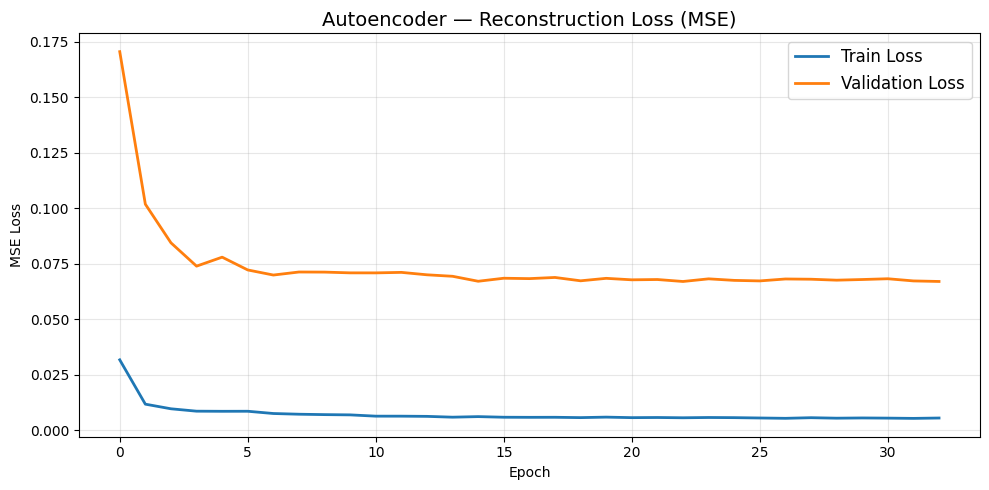

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(ae_history.history['loss'], label='Train Loss', linewidth=2)
ax.plot(ae_history.history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_title('Autoencoder — Reconstruction Loss (MSE)', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

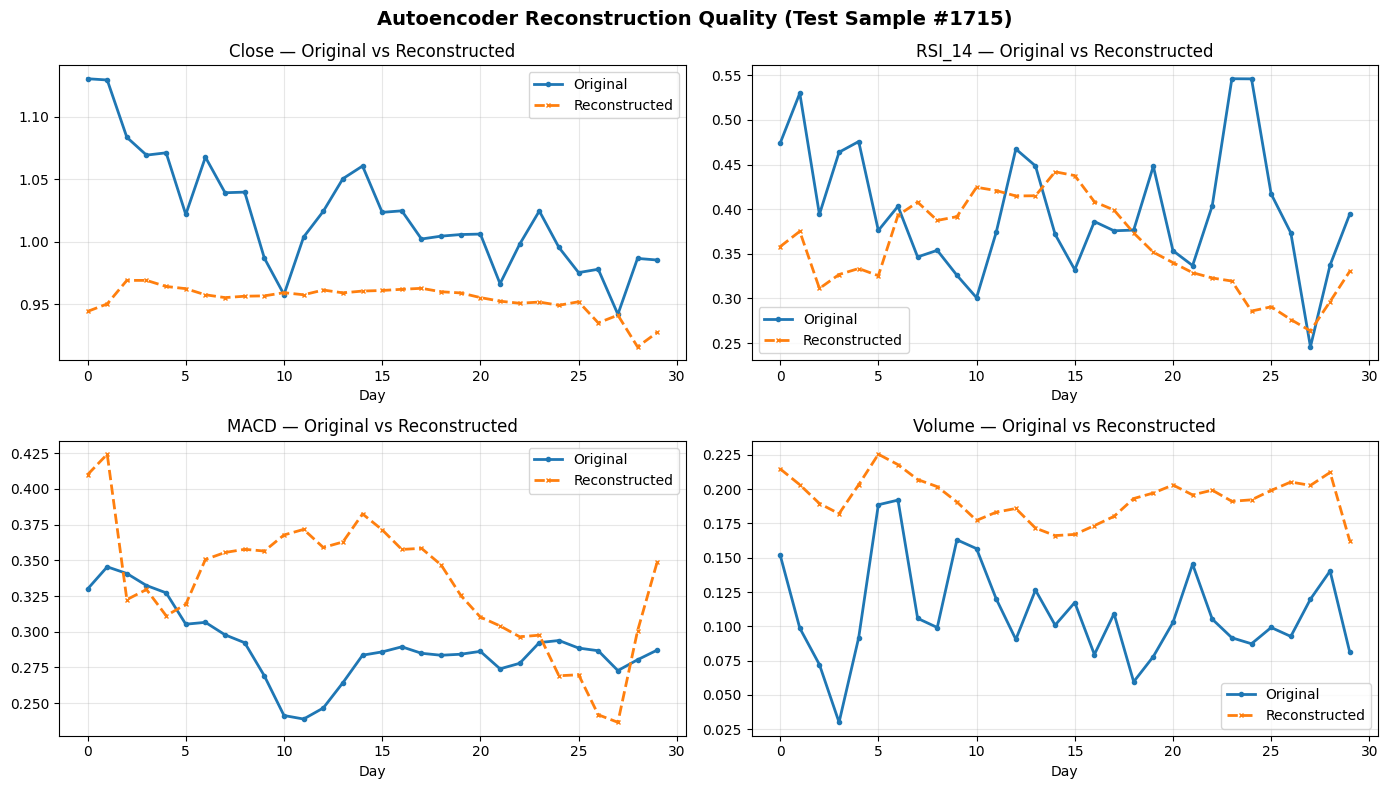

In [26]:
sample_idx = np.random.randint(0, len(X_test))
original = X_test[sample_idx]
reconstructed = autoencoder.predict(X_test[sample_idx:sample_idx+1], verbose=0)[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
features_to_plot = ['Close', 'RSI_14', 'MACD', 'Volume']
feature_indices = [FEATURE_COLS.index(f) for f in features_to_plot]

for i, (feat_name, feat_idx) in enumerate(zip(features_to_plot, feature_indices)):
    ax = axes[i // 2][i % 2]
    ax.plot(original[:, feat_idx], label='Original', linewidth=2, marker='o', markersize=3)
    ax.plot(reconstructed[:, feat_idx], label='Reconstructed', linewidth=2, linestyle='--', marker='x', markersize=3)
    ax.set_title(f'{feat_name} — Original vs Reconstructed', fontsize=12)
    ax.set_xlabel('Day')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Autoencoder Reconstruction Quality (Test Sample #{sample_idx})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
def build_cnn_classifier(window_size, n_features):
    """
    1D-CNN for binary classification (UP/DOWN prediction).
    Input shape: (window_size, n_features) = (30, 12)
    Output: probability of UP (sigmoid)
    """
    model = keras.Sequential([
        # --- Conv Block 1 ---
        layers.Conv1D(64, kernel_size=3, activation='relu',
                      input_shape=(window_size, n_features), name='conv1'),
        layers.BatchNormalization(name='bn1'),
        layers.MaxPooling1D(pool_size=2, name='pool1'),

        # --- Conv Block 2 ---
        layers.Conv1D(128, kernel_size=3, activation='relu', name='conv2'),
        layers.BatchNormalization(name='bn2'),
        layers.MaxPooling1D(pool_size=2, name='pool2'),

        # --- Conv Block 3 ---
        layers.Conv1D(64, kernel_size=3, activation='relu', name='conv3'),
        layers.BatchNormalization(name='bn3'),

        # --- Global Average Pooling (better than Flatten for reducing overfitting) ---
        layers.GlobalAveragePooling1D(name='global_avg_pool'),

        # --- Classification Head ---
        layers.Dropout(0.3, name='dropout1'),
        layers.Dense(64, activation='relu', name='dense1'),
        layers.Dropout(0.2, name='dropout2'),
        layers.Dense(1, activation='sigmoid', name='output')
    ], name='CNN_Classifier')

    return model

# Build
cnn_model = build_cnn_classifier(WINDOW_SIZE, len(FEATURE_COLS))

# Compile
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("=" * 60)
print(" 1D-CNN CLASSIFIER Architecture")
print("=" * 60)
cnn_model.summary()

 1D-CNN CLASSIFIER Architecture


Model: "CNN_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv1D)                  │ (None, 28, 64)         │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 28, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 12, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 12, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 4, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,961 (222.50 KB)

 Trainable params: 56,449 (220.50 KB)

 Non-trainable params: 512 (2.00 KB)

In [31]:

cnn_history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6
        )
    ],
    verbose=1
)

print(f"\n CNN training complete!")
print(f"   Best val_accuracy: {max(cnn_history.history['val_accuracy']):.4f}")


Epoch 1/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.4807 - loss: 0.7811 - val_accuracy: 0.4673 - val_loss: 0.7010 - learning_rate: 0.0010
Epoch 2/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5031 - loss: 0.7306 - val_accuracy: 0.4775 - val_loss: 0.7021 - learning_rate: 0.0010
Epoch 3/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4970 - loss: 0.7167 - val_accuracy: 0.4650 - val_loss: 0.7912 - learning_rate: 0.0010
Epoch 4/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5161 - loss: 0.7079 - val_accuracy: 0.5322 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 5/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5234 - loss: 0.7054 - val_accuracy: 0.5122 - val_loss: 0.6953 - learning_rate: 0.0010
Epoch 6/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4907 - loss: 0.7081 - val_accuracy: 0.4957 - val_loss: 0.6996 - learning_rate: 0.0010
Epoch 7/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5239 - loss: 0.

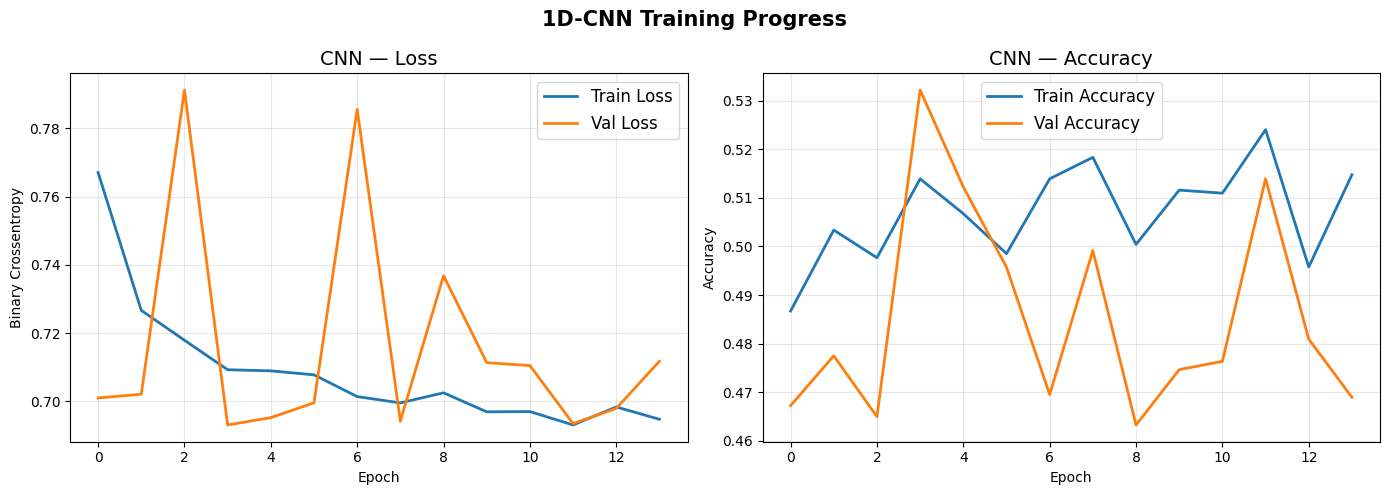

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(cnn_history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(cnn_history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('CNN — Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(cnn_history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(cnn_history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_title('CNN — Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('1D-CNN Training Progress', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [33]:
y_pred_prob = cnn_model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrics
test_accuracy = accuracy_score(y_test, y_pred)

print("=" * 60)
print(" CNN — TEST SET EVALUATION")
print("=" * 60)
print(f"\n Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['DOWN (0)', 'UP (1)']))

 CNN — TEST SET EVALUATION

 Test Accuracy: 0.5171 (51.71%)

 Classification Report:
              precision    recall  f1-score   support

    DOWN (0)       0.38      0.02      0.03       826
      UP (1)       0.52      0.97      0.68       903

    accuracy                           0.52      1729
   macro avg       0.45      0.50      0.36      1729
weighted avg       0.45      0.52      0.37      1729



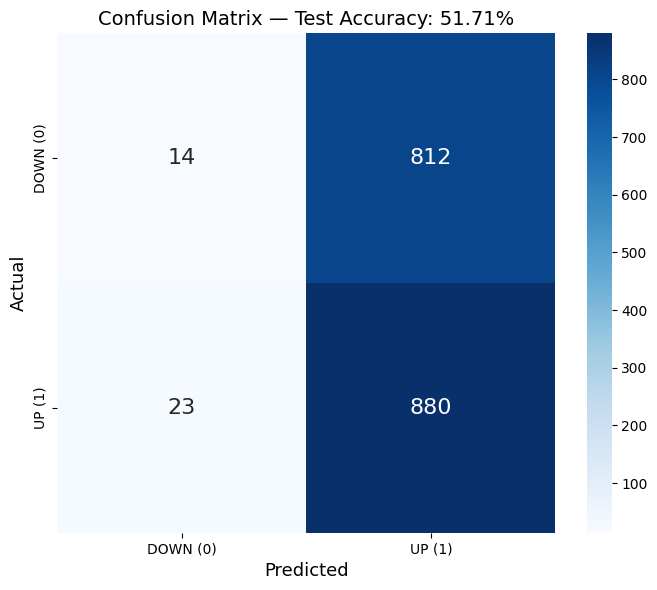


 Summary:
   True Negatives (correctly predicted DOWN):  14
   False Positives (predicted UP, was DOWN):   812
   False Negatives (predicted DOWN, was UP):   23
   True Positives (correctly predicted UP):    880


In [34]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['DOWN (0)', 'UP (1)'],
            yticklabels=['DOWN (0)', 'UP (1)'],
            annot_kws={'size': 16}, ax=ax)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title(f'Confusion Matrix — Test Accuracy: {test_accuracy:.2%}', fontsize=14)
plt.tight_layout()
plt.show()

# Print summary
print(f"\n Summary:")
print(f"   True Negatives (correctly predicted DOWN):  {cm[0][0]}")
print(f"   False Positives (predicted UP, was DOWN):   {cm[0][1]}")
print(f"   False Negatives (predicted DOWN, was UP):   {cm[1][0]}")
print(f"   True Positives (correctly predicted UP):    {cm[1][1]}")

In [36]:
# CELL 15: Save Models

import os

# Create directories
os.makedirs('../saved_models/deep_learning', exist_ok=True)

# Save Autoencoder (full model)
autoencoder.save('../saved_models/deep_learning/qusay_models/autoencoder.keras')
print(" Autoencoder saved → saved_models/deep_learning/qusay_models/autoencoder.keras")

# Save Encoder only (for feature extraction)
encoder.save('../saved_models/deep_learning/qusay_models/encoder.keras')
print(" Encoder saved → saved_models/deep_learning/qusay_models/encoder.keras")

# Save CNN Classifier
cnn_model.save('../saved_models/deep_learning/qusay_models/cnn_classifier.keras')
print(" CNN Classifier saved → saved_models/deep_learning/qusay_models/cnn_classifier.keras")

print(f"\n All models saved successfully!")


 Autoencoder saved → saved_models/deep_learning/qusay_models/autoencoder.keras
 Encoder saved → saved_models/deep_learning/qusay_models/encoder.keras
 CNN Classifier saved → saved_models/deep_learning/qusay_models/cnn_classifier.keras

 All models saved successfully!
